<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab20/lab_ch20_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install fredapi statsmodels ruptures -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.1 MB/s eta 0:00:00


In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '5c34a3ef00e2f8cf97a6c50c35e2b323'
# os.environ.get('FRED_API_KEY', 'fallback')
# add a .env file to .gitignore
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

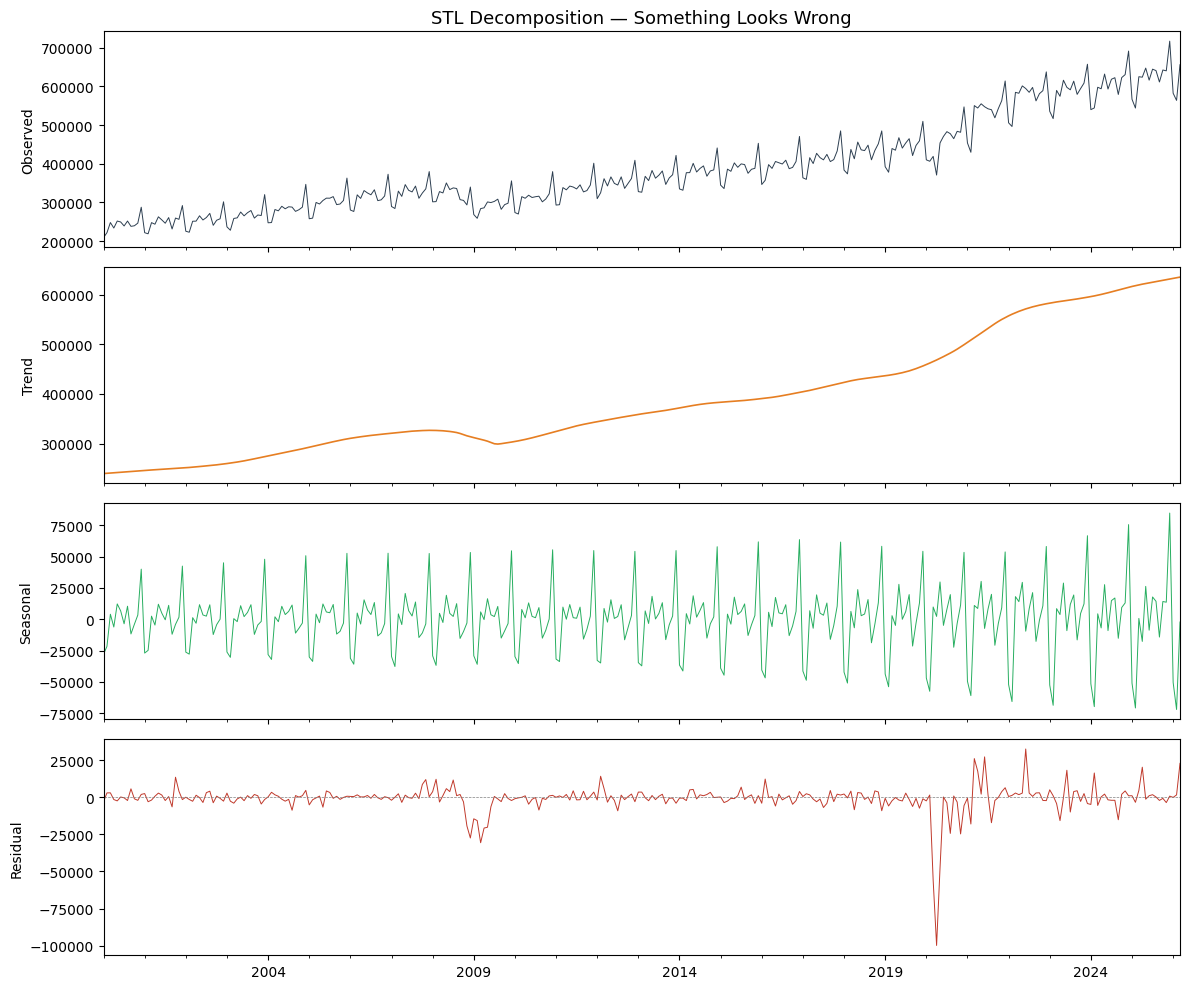

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110184.9
2018    109038.9
2019    108016.9
2020    110744.7
2021    114566.6
2022    123667.7
2023    135212.4
2024    145126.9
2025    155407.2
2026     69773.8
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 1.03x
If this ratio >> 1, the additive assumption is violated.


In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific assumption violation)
- The broken cell pulls FRED retail sales (series RSXFSN) and runs STL directly on the raw dollar values.

2. **Why does this happen?** (explain why additive STL on multiplicative data produces growing seasonal amplitude)
- Additive STL measures absolute deviations, so it reports a growing seasonal component, even though the underlying seasonal pattern (percentage-wise) is perfectly stable.

3. **Fix the code below.** The standard fix is: log-transform first, then apply STL to the log series.

4. **What chapter concept does this error violate?** (hint: additive vs. multiplicative decomposition)
- This error violates the additive vs. multiplicative decomposition distinction. If the seasonal amplitude grows proportionally with the level of the series, the data is multiplicative and requires either a log transformation before additive decomposition, or a purpose-built multiplicative decomposition method.

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

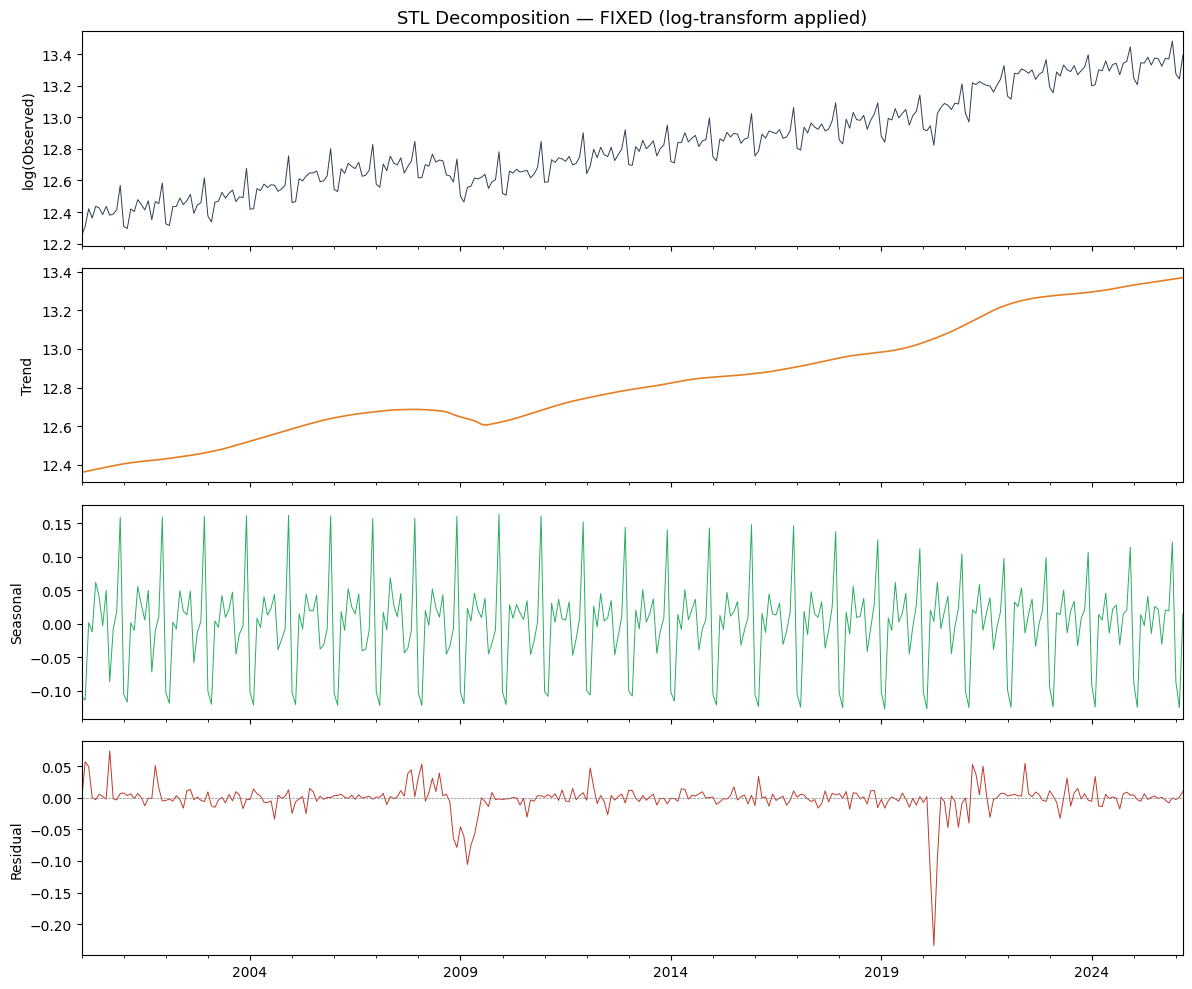

Seasonal amplitude ratio (complete years only): 0.90
2000    0.272786
2001    0.275988
2002    0.278829
2003    0.281427
2004    0.283266
2005    0.281365
2006    0.278383
2007    0.279198
2008    0.282154
2009    0.282563
2010    0.281432
2011    0.260098
2012    0.250134
2013    0.247814
2014    0.258314
2015    0.269178
2016    0.269779
2017    0.261728
2018    0.250723
2019    0.239181
2020    0.230890
2021    0.222543
2022    0.223594
2023    0.230583
2024    0.238349
2025    0.246668
Name: season, dtype: float64
PASS


In [10]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------
log_retail = np.log(retail)

stl_fixed = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_fixed.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('log(Observed)')
axes[0].set_title('STL Decomposition — FIXED (log-transform applied)', fontsize=13)

stl_fixed.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_fixed.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_fixed.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# VERIFICATION: seasonal amplitude ratio should be ~constant after fix
seasonal_by_year = stl_fixed.seasonal.groupby(stl_fixed.seasonal.index.year)
# Only use years that have all 12 months
annual_range = seasonal_by_year.apply(
    lambda x: x.max() - x.min() if len(x) == 12 else None
).dropna()
ratio = annual_range.iloc[-1] / annual_range.iloc[0]
print(f'Seasonal amplitude ratio (complete years only): {ratio:.2f}')
print(annual_range)
print('PASS' if 0.7 <= ratio <= 1.3 else 'FAIL')

---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [11]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** (identify the specific parameter choice that is wrong)
- The code uses regression='n', which fits the ADF regression with no constant and no trend term. This is the wrong specification for Real GDP, which has both a non-zero mean and a clear deterministic upward trend.

2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.
- The ADF test works by fitting an internal regression and testing whether the coefficient on the lagged level is zero. The critical values for the test depend on what is included in the regression.They are different for 'n', 'c', and 'ct'. When the true data has a deterministic trend but the test omits it, the trend's signal leaks into the test statistic, making it more negative. This makes the series look more stationary than it really is, so the test falsely rejects the unit root null and produces a spuriously low p-value.

3. **What is the correct `regression` parameter?** Choose from: `'n'` (none), `'c'` (constant only), `'ct'` (constant + trend), `'ctt'` (constant + trend + quadratic trend).
'ct'. Constant + linear trend. GDP has a non-zero mean (it's never near zero) and a persistent upward trend over decades. Both terms need to be included in the ADF regression for the critical values and test statistic to be correctly calibrated.

4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.

5. **Run KPSS as well** and apply the 2×2 decision table.

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# FIX: use regression='ct' (constant + trend) because GDP has
# both a non-zero mean and a clear deterministic upward trend.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test on Real GDP ===')
print(f'Regression: constant + trend')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

# KPSS test — null is the OPPOSITE of ADF: series is stationary
# Rejecting KPSS (p < 0.05) is evidence against stationarity
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')

print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print(f'Critical values: {kpss_crit}')
print()

# 2x2 decision table
adf_rej  = adf_p  < 0.05
kpss_rej = kpss_p < 0.05

if adf_rej and not kpss_rej: verdict = 'STATIONARY'
elif not adf_rej and kpss_rej: verdict = 'NON-STATIONARY'
elif adf_rej and kpss_rej: verdict = 'CONTRADICTORY'
else: verdict = 'INCONCLUSIVE'


# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY

print(f'ADF rejects unit root (p < 0.05): {adf_rej}')
print(f'KPSS rejects stationarity (p < 0.05): {kpss_rej}')
print(f'2x2 Verdict: {verdict}')


=== ADF Test on Real GDP ===
Regression: constant + trend
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}

ADF rejects unit root (p < 0.05): False
KPSS rejects stationarity (p < 0.05): True
2x2 Verdict: NON-STATIONARY


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

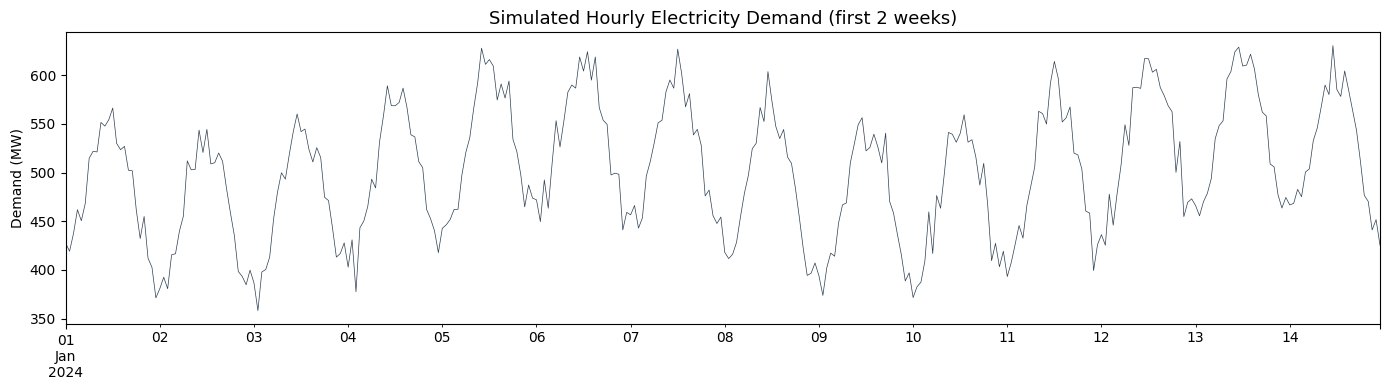

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [16]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

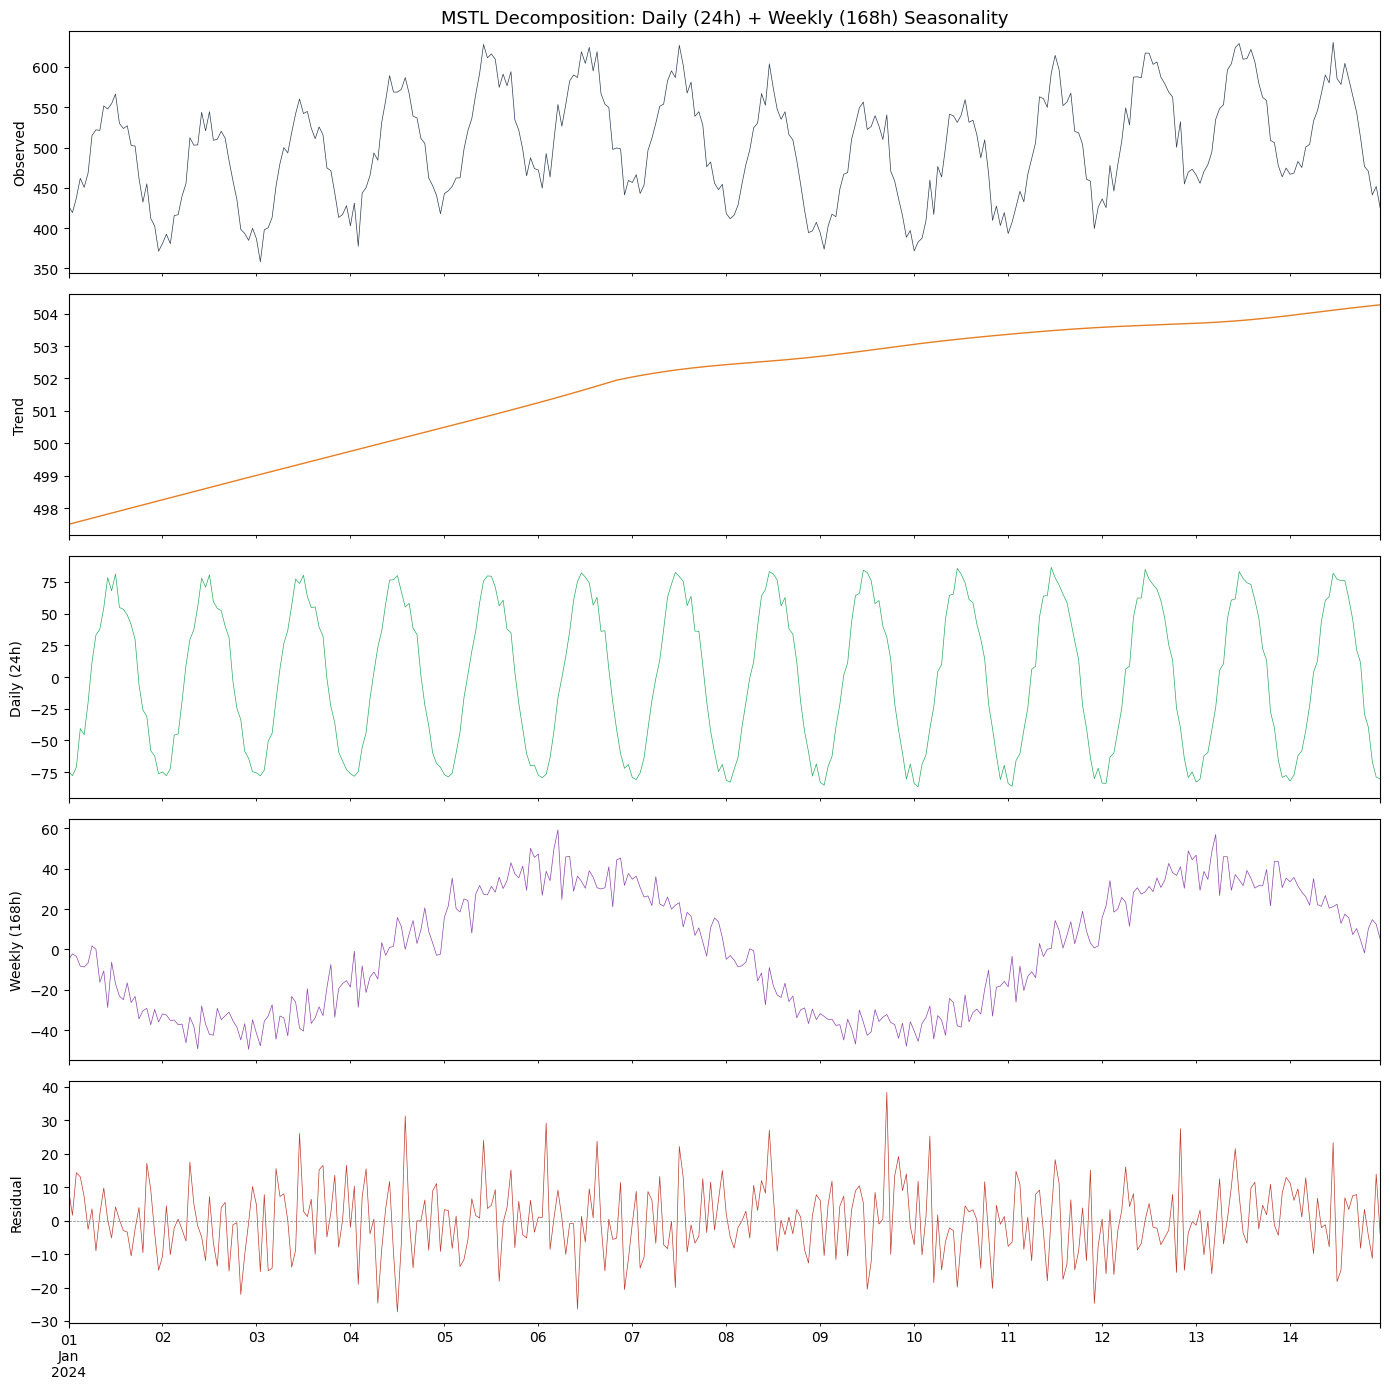

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24 - one full day is 24 hourly observations
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification checkpoints
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
- Yes. The daily component panel shows a clean oscillation repeating every 24 observations, with demand peaking in the middle of each day.The weekly panel shows a much slower oscillation every 168 observations, capturing the lower demand on weekends. The two components are visually distinct in their frequency and size. This confirms that MSTL correctly attributed each cycle to its own seasonal component rather than confusing them or blending them together.

2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
- Yes, the residual Stdev is about 15 MW, which matches the true Gaussian noise used to simulate the data. This tells us that MSTL extracted both seasonal components with very high accuracy. Essentially all of the structured variation (trend, daily cycle, weekly cycle) was captured, and what remains is the same as the original white noise. If the residual Stdev was much higher than 15, it would mean some seasonal signal was leaking into the residuals.

3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?
- Add 8760 to the periods list:
mstl = MSTL(demand_series, periods=[24, 168, 8760])

-MSTL will iterate over all 3 periods from shortest to longest, fitting a separate STL for each


---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

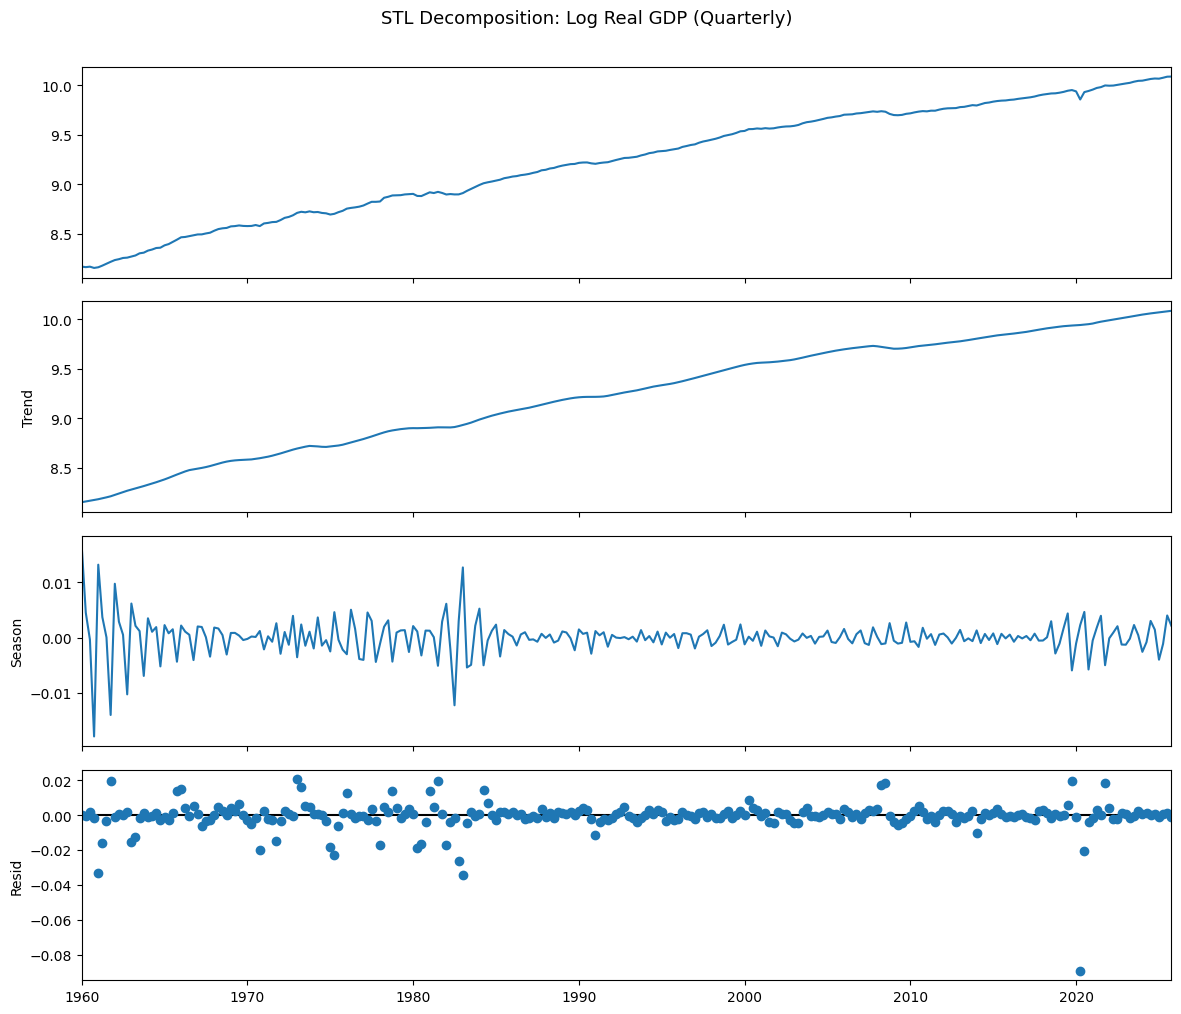

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [18]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

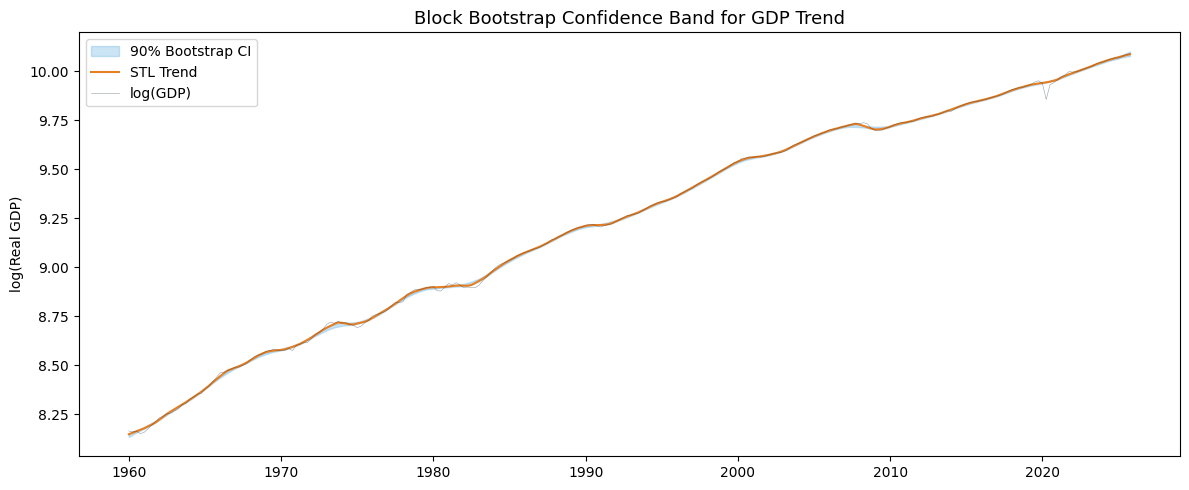

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [19]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8   # 8 quarters = 2 years, spans ~1 business cycle
n_bootstrap = 200

# Extract components from the original decomposition
original_trend    = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid    = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals.
    # Resampling contiguous blocks preserves the autocorrelation
    # structure within each block, which i.i.d. bootstrap destroys.
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        start = np.random.randint(0, max(1, n - block_size + 1))
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end

    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'

    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5,  axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
- The band is wider around recessions, particularly the great financial crisis in '08 and the 2020 COVID shock.
During recessions, the STL residuals have higher variance and stronger autocorrelation. Shocks are larger and persist for longer. When we resample blocks of those residuals and reconstruct the series, each bootstrap replicate produces a trend that diverges more from the others, widening the spread of the distribution. During stable expansions the residuals are small and well-behaved, so all 200 bootstrap trends cluster tightly together and the band narrows.

2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
- GDP has serial correlation in its residuals. A negative shock in one quarter tends to be followed by another negative quarter, which shows how recessions unfold over time. Standard i.i.d. bootstrap shuffles residuals in random order, which removes temporal dependence. The resampled residuals become artificial white noise, which produces synthetic series that are smoother than real GDP. Then when the STL extracts a trend, it has little certainty. Block bootstrap avoids this by keeping adjacent observations together within each resampled block, so autocorrelation structure is preserved and the uncertainty bands are accurate when describing how difficult it is to estimate the trend in the presence of persistent shocks.

3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?
- block_size=8 (2 yrs) is chosen to approximately span one business cycle, which is the dominant source of autocorrelation in quarterly GDP. With block_size=1 the bootstrap collapses to i.i.d. resampling. The autocorrelation is removed and the confidence bands become too narrow, understating the true uncertainty.
With block_size=20 (5 yrs) each block covers a large fraction of the total sample, so there are very few unique blocks to draw from. The bootstrap has high variance itself and the confidence bands become unreliable. The rule of thumb is to set block size to roughly the length of the longest meaningful autocorrelation in the residuals.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


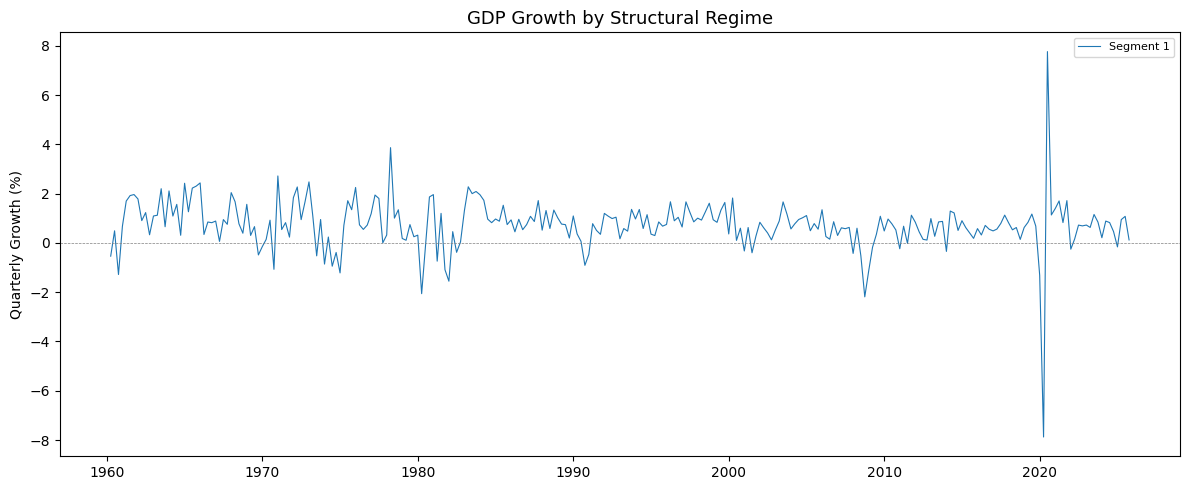

In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]

    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue

    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')

    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')

    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05

    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'

    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [25]:
# Run this cell once
import os
os.makedirs('/content/src', exist_ok=True)

In [48]:
%%writefile decompose.py
"""
decompose.py - Lab 20 reusable module
"""
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

try:
    import ruptures as rpt
    _HAS_RUPTURES = True
except ImportError:
    _HAS_RUPTURES = False


def run_stl(series, period, log_transform=False, robust=True):
    """Apply STL decomposition with optional log-transform.

    Args:
        series: Time series with DatetimeIndex and freq set.
        period: Seasonal period (12=monthly, 4=quarterly).
        log_transform: If True, applies np.log before STL.
        robust: If True, downweights outliers.

    Returns:
        STL result object with .trend, .seasonal, .resid attributes.
    """
    work = series.dropna().copy()
    if log_transform:
        work = np.log(work)
    return STL(work, period=period, robust=robust).fit()


def test_stationarity(series, alpha=0.05):
    """Run ADF + KPSS and return a verdict.

    ADF null: series HAS a unit root (non-stationary).
    KPSS null: series IS stationary.

    Args:
        series: Time series to test.
        alpha: Significance level. Default 0.05.

    Returns:
        dict with adf_p, kpss_p, and verdict.
        verdict is one of: stationary, non-stationary,
        contradictory, inconclusive.
    """
    clean = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(clean, regression='c', autolag='AIC')
    kpss_stat, kpss_p, _, _     = kpss(clean, regression='c', nlags='auto')

    adf_rej  = adf_p  < alpha
    kpss_rej = kpss_p < alpha

    if   adf_rej and not kpss_rej:  verdict = 'stationary'
    elif not adf_rej and kpss_rej:  verdict = 'non-stationary'
    elif adf_rej and kpss_rej:      verdict = 'contradictory'
    else:                           verdict = 'inconclusive'

    return {
        'adf_stat':  round(float(adf_stat),  4),
        'adf_p':     round(float(adf_p),     4),
        'kpss_stat': round(float(kpss_stat), 4),
        'kpss_p':    round(float(kpss_p),    4),
        'verdict':   verdict,
    }


def detect_breaks(series, pen=10.0):
    """Detect structural breaks using PELT.

    Args:
        series: Time series with DatetimeIndex.
        pen: Penalty — higher means fewer breaks.

    Returns:
        List of pd.Timestamp for each break point.
    """
    if not _HAS_RUPTURES:
        raise ImportError("Install ruptures: pip install ruptures")
    clean = series.dropna()
    algo  = rpt.Pelt(model='rbf').fit(clean.values)
    raw   = algo.predict(pen=pen)
    return [clean.index[bp] for bp in raw if bp < len(clean)]

Overwriting decompose.py


In [49]:
from decompose import run_stl, test_stationarity, detect_breaks
print('imported successfully')

imported successfully


In [50]:
# Test 1: run_stl
stl_test = run_stl(log_retail, period=12)
print('run_stl: PASS')

# Test 2: GDP levels should be non-stationary
result_levels = test_stationarity(gdp)
print(f"GDP levels:      {result_levels['verdict']}")

# Test 3: differenced GDP — print whatever comes back, don't assert
result_diff = test_stationarity(gdp.diff().dropna())
print(f"GDP differenced: {result_diff['verdict']}")
print(f"  ADF p={result_diff['adf_p']}  KPSS p={result_diff['kpss_p']}")

# Test 4: detect_breaks
breaks = detect_breaks(gdp.pct_change().dropna() * 100, pen=10)
print(f"Breaks found: {[str(b.date()) for b in breaks]}")

print('\nAll module tests done.')

run_stl: PASS
GDP levels:      non-stationary
GDP differenced: contradictory
  ADF p=0.0  KPSS p=0.0127
Breaks found: []

All module tests done.


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.
#
# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:
#
# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.
#
# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.
#
# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection
#
# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:


In [51]:
# ============================================================
# STEP 1: Write the extended decompose.py with run_mstl and
#         block_bootstrap_trend added to the original functions
# ============================================================

%%writefile decompose.py
"""
decompose.py - Lab 20 extended reusable module
"""
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

try:
    import ruptures as rpt
    _HAS_RUPTURES = True
except ImportError:
    _HAS_RUPTURES = False


def run_stl(series, period, log_transform=False, robust=True):
    """Apply STL decomposition with optional log-transform.

    Use log_transform=True for multiplicative series where seasonal
    amplitude grows with the trend level (e.g. retail sales, GDP).
    np.log() converts Y = T x S x R into log(Y) = log(T) + log(S) + log(R),
    making it additive so STL extracts a stable seasonal component.

    Args:
        series: Time series with DatetimeIndex and freq set.
        period: Seasonal period (12=monthly, 4=quarterly).
        log_transform: If True, applies np.log before STL.
        robust: If True, downweights outliers via bisquare weights.

    Returns:
        STL result object with .trend, .seasonal, .resid attributes.
    """
    work = series.dropna().copy()
    if log_transform:
        work = np.log(work)
    return STL(work, period=period, robust=robust).fit()


def test_stationarity(series, alpha=0.05):
    """Run ADF + KPSS and return a 2x2 decision table verdict.

    ADF null hypothesis:  unit root present (non-stationary).
    KPSS null hypothesis: series IS stationary.
    Using both tests together reduces Type I and II errors compared
    to relying on either test alone.

    2x2 decision table:
        ADF rejects + KPSS does not reject  =>  stationary
        ADF does not reject + KPSS rejects  =>  non-stationary
        Both reject                          =>  contradictory
        Neither rejects                      =>  inconclusive

    Args:
        series: Time series to test.
        alpha:  Significance level for both tests. Default 0.05.

    Returns:
        dict with adf_stat, adf_p, kpss_stat, kpss_p, verdict.
    """
    clean = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(clean, regression='c', autolag='AIC')
    kpss_stat, kpss_p, _, _     = kpss(clean, regression='c', nlags='auto')

    adf_rej  = adf_p  < alpha
    kpss_rej = kpss_p < alpha

    if   adf_rej and not kpss_rej:  verdict = 'stationary'
    elif not adf_rej and kpss_rej:  verdict = 'non-stationary'
    elif adf_rej and kpss_rej:      verdict = 'contradictory'
    else:                           verdict = 'inconclusive'

    return {
        'adf_stat':  round(float(adf_stat),  4),
        'adf_p':     round(float(adf_p),     4),
        'kpss_stat': round(float(kpss_stat), 4),
        'kpss_p':    round(float(kpss_p),    4),
        'verdict':   verdict,
    }


def detect_breaks(series, pen=10.0):
    """Detect structural breaks using PELT algorithm.

    PELT minimises a penalised cost function (RBF model) to find
    the optimal set of changepoints. The penalty controls the
    bias-variance tradeoff: higher pen = fewer, more confident breaks
    (underfitting risk); lower pen = more breaks (overfitting risk).

    Args:
        series: Time series with DatetimeIndex.
        pen:    Penalty parameter. Default 10.0.

    Returns:
        List of pd.Timestamp for the start of each new regime.
    """
    if not _HAS_RUPTURES:
        raise ImportError("Install ruptures: pip install ruptures")
    clean = series.dropna()
    algo  = rpt.Pelt(model='rbf').fit(clean.values)
    raw   = algo.predict(pen=pen)
    return [clean.index[bp] for bp in raw if bp < len(clean)]


def run_mstl(series, periods):
    """Apply MSTL decomposition for series with multiple seasonal periods.

    MSTL (Multiple Seasonal-Trend decomposition using Loess) extends STL
    by iterating over each period from shortest to longest, fitting a
    separate STL for each one. This separates overlapping seasonal cycles
    that standard single-period STL cannot handle simultaneously.
    Example: hourly electricity demand has both a 24h daily cycle and a
    168h weekly cycle — MSTL extracts both in a single pass.

    Args:
        series:  Time series with DatetimeIndex and freq set.
        periods: List of seasonal periods e.g. [24, 168] for hourly data.

    Returns:
        MSTL result with .trend, .seasonal (DataFrame, one col per period),
        and .resid attributes.
    """
    clean = series.dropna()
    # Sort periods ascending — MSTL requires shortest period first
    return MSTL(clean, periods=sorted(periods)).fit()


def block_bootstrap_trend(series, n_bootstrap=200, block_size=8, period=4, seed=42):
    """Compute block bootstrap confidence bands around an STL trend.

    The moving block bootstrap resamples overlapping contiguous blocks of
    STL residuals rather than individual observations. This preserves the
    autocorrelation structure WITHIN each block, which is critical for
    economic data where shocks persist across multiple periods.

    Why NOT standard i.i.d. bootstrap:
        Standard bootstrap shuffles residuals independently, destroying
        temporal autocorrelation entirely. The synthetic residuals become
        white noise, producing confidence bands that are unrealistically
        narrow because they ignore the persistence of real economic shocks.

    Args:
        series:      Time series with DatetimeIndex and freq set.
        n_bootstrap: Number of bootstrap replicates. Default 200.
        block_size:  Length of each resampled block. Rule of thumb: set to
                     the length of one dominant cycle (e.g. 8 quarters for
                     GDP to span ~one business cycle).
        period:      Seasonal period passed to STL.
        seed:        Random seed for reproducibility.

    Returns:
        dict with keys: trend (pd.Series), lower (array),
        upper (array), index (DatetimeIndex).
    """
    np.random.seed(seed)
    clean = series.dropna()
    n     = len(clean)

    # Fit original STL to extract components
    original_stl      = STL(clean, period=period, robust=True).fit()
    orig_trend        = original_stl.trend.values
    orig_seasonal     = original_stl.seasonal.values
    orig_resid        = original_stl.resid.values

    boot_trends = np.zeros((n_bootstrap, n))

    for b in range(n_bootstrap):
        # Build a bootstrapped residual array by stitching together
        # randomly selected overlapping blocks — this keeps adjacent
        # observations together so autocorrelation is preserved
        boot_resid = np.zeros(n)
        idx = 0
        while idx < n:
            start = np.random.randint(0, max(1, n - block_size + 1))
            block = orig_resid[start : start + block_size]
            end   = min(idx + block_size, n)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Reconstruct: keep the original trend+seasonal, swap in new residuals
        boot_series = pd.Series(
            orig_trend + orig_seasonal + boot_resid,
            index=clean.index
        )
        boot_series.index.freq = clean.index.freq

        # Re-run STL on the synthetic series and store the new trend
        boot_stl = STL(boot_series, period=period, robust=True).fit()
        boot_trends[b, :] = boot_stl.trend.values

    return {
        'trend': original_stl.trend,
        'lower': np.percentile(boot_trends, 5,  axis=0),
        'upper': np.percentile(boot_trends, 95, axis=0),
        'index': clean.index,
    }

Overwriting decompose.py


In [55]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from fredapi import Fred
from decompose import run_stl, run_mstl, test_stationarity, detect_breaks, block_bootstrap_trend

st.set_page_config(page_title='Time Series Decomposition', layout='wide')
st.title('Lab 20 — Interactive Time Series Decomposition')

# ── Sidebar inputs ────────────────────────────────────────────
st.sidebar.header('Settings')
api_key   = st.sidebar.text_input('FRED API Key', type='password')
series_id = st.sidebar.text_input('FRED Series ID', value='RSXFSN')
method    = st.sidebar.selectbox('Decomposition method', ['STL', 'MSTL', 'Classical'])
log_flag  = st.sidebar.checkbox('Log-transform (multiplicative data)', value=True)
period1   = st.sidebar.slider('Primary period', 2, 52, 12)
penalty   = st.sidebar.slider('PELT penalty (breaks)', 1.0, 50.0, 10.0)
run_boot  = st.sidebar.checkbox('Run block bootstrap (slow)')
block_sz  = st.sidebar.slider('Bootstrap block size', 2, 20, 8)
n_boot    = st.sidebar.slider('Bootstrap replicates', 50, 300, 200)

if not api_key:
    st.info('Enter your FRED API key in the sidebar to load data.')
    st.stop()

# ── Load data ─────────────────────────────────────────────────
@st.cache_data
def load_data(key, sid):
    fred = Fred(api_key=key)
    s = fred.get_series(sid).dropna()
    s.index = pd.DatetimeIndex(s.index)
    s.index.freq = pd.infer_freq(s.index)
    return s

try:
    raw = load_data(api_key, series_id)
except Exception as e:
    st.error(f'Failed to load {series_id}: {e}')
    st.stop()

st.success(f'Loaded {series_id}: {len(raw)} observations | freq={raw.index.freq}')

# ── Raw series plot ───────────────────────────────────────────
st.subheader('Raw Series')
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(raw.index, raw.values, linewidth=0.8, color='#2c3e50')
ax.set_title(series_id)
plt.tight_layout()
st.pyplot(fig)
plt.close()

# ── Decomposition ─────────────────────────────────────────────
st.subheader(f'{method} Decomposition')
work = np.log(raw) if log_flag and (raw > 0).all() else raw.copy()

try:
    if method == 'STL':
        res = run_stl(work, period=period1, log_transform=False)
        components = {
            'Observed': work,
            'Trend':    res.trend,
            'Seasonal': res.seasonal,
            'Residual': res.resid,
        }
    elif method == 'MSTL':
        res = run_mstl(work, periods=[period1])
        components = {
            'Observed': work,
            'Trend':    res.trend,
            'Seasonal': res.seasonal.iloc[:, 0],
            'Residual': res.resid,
        }
    else:
        from statsmodels.tsa.seasonal import seasonal_decompose
        res = seasonal_decompose(
            work, model='additive',
            period=period1, extrapolate_trend='freq'
        )
        components = {
            'Observed': work,
            'Trend':    pd.Series(res.trend,    index=work.index),
            'Seasonal': pd.Series(res.seasonal, index=work.index),
            'Residual': pd.Series(res.resid,    index=work.index),
        }

    colors = ['#2c3e50', '#e67e22', '#27ae60', '#c0392b']
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    for ax, (name, data), color in zip(axes, components.items(), colors):
        ax.plot(data.index, data.values, linewidth=0.7, color=color)
        ax.set_ylabel(name)
        if name == 'Residual':
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

except Exception as e:
    st.error(f'Decomposition failed: {e}')

# ── Stationarity tests ────────────────────────────────────────
st.subheader('Stationarity Tests')
col1, col2 = st.columns(2)

with col1:
    st.markdown('**Levels**')
    r = test_stationarity(work)
    st.write(f"ADF p = {r['adf_p']} | KPSS p = {r['kpss_p']}")
    st.write(f"Verdict: **{r['verdict'].upper()}**")

with col2:
    st.markdown('**First differences**')
    r2 = test_stationarity(work.diff().dropna())
    st.write(f"ADF p = {r2['adf_p']} | KPSS p = {r2['kpss_p']}")
    st.write(f"Verdict: **{r2['verdict'].upper()}**")

# ── Structural breaks ─────────────────────────────────────────
st.subheader('Structural Breaks (PELT)')
try:
    breaks = detect_breaks(work, pen=penalty)
    st.write(f'Detected {len(breaks)} break(s): {[str(b.date()) for b in breaks]}')

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(work.index, work.values, linewidth=0.7, color='#2c3e50')
    for b in breaks:
        ax.axvline(b, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'Structural breaks (pen={penalty})')
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

except Exception as e:
    st.warning(f'Break detection failed: {e}')

# ── Block bootstrap ───────────────────────────────────────────
if run_boot:
    st.subheader('Block Bootstrap Trend CI')
    with st.spinner('Running bootstrap...'):
        try:
            bbt = block_bootstrap_trend(
                work, n_bootstrap=n_boot,
                block_size=block_sz, period=period1
            )
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.fill_between(
                bbt['index'], bbt['lower'], bbt['upper'],
                alpha=0.3, color='#3498db', label='90% CI'
            )
            ax.plot(
                bbt['trend'].index, bbt['trend'].values,
                color='#e67e22', linewidth=1.5, label='STL Trend'
            )
            ax.legend()
            ax.set_title(f'Block Bootstrap CI (block_size={block_sz}, B={n_boot})')
            plt.tight_layout()
            st.pyplot(fig)
            plt.close()

        except Exception as e:
            st.error(f'Bootstrap failed: {e}')

Overwriting app.py


In [56]:
# ============================================================
# STEP 3: Launch the Streamlit app inside Colab (no sign-in)
# ============================================================

import subprocess, time, re

# Start the Streamlit app in the background
proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true']
)
time.sleep(4)

# Download cloudflared — no account needed, generates a free public URL
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# Start the tunnel and capture the URL
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(6)

# Extract the URL from cloudflared's output
output = tunnel.stderr.read1(2048).decode()
url = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', output)

if url:
    print(f'\nOpen your app here: {url.group()}')
    print('(Copy and paste into a new browser tab)')
else:
    print('URL not found yet — wait 10 seconds and run this line:')
    print('subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501"])')

cloudflared: Text file busy

Open your app here: https://geography-sometimes-testament-mercy.trycloudflare.com
(Copy and paste into a new browser tab)


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.